In [1]:
from data import *

In [2]:
X, y = data_gen((1,2,3), num_negative=200, num_positive=200, margin=.5)

In [3]:
y_01 = (y+1)/2

In [4]:
save_dataset(X,y,"dataset/data1.npy")

Saved dataset/data1.npy_X.npy and dataset/data1.npy_y.npy


In [5]:
model, trained_plane = train_svm_get_hyperplane(X, y)

Trained SVM hyperplane: (1.2501739344801372, 2.9826626656277, 4.433194395478239)


In [6]:
import matplotlib.pyplot as plt

def plot_svm_decision_boundary(model, X, y):
    """
    Plot the decision boundary of a trained SVM model for 2D data.
    
    Parameters:
        model: Trained SVM model.
        X (np.ndarray): Feature matrix (2D).
        y (np.ndarray): Labels (-1 or +1).
    """
    plt.figure(figsize=(8, 6))
    
    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    
    # Create grid for decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Compute decision boundary
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["blue", "black", "red"], linestyles=["dashed", "solid", "dashed"])
    
    plt.title("SVM Decision Boundary (Hard Margin)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


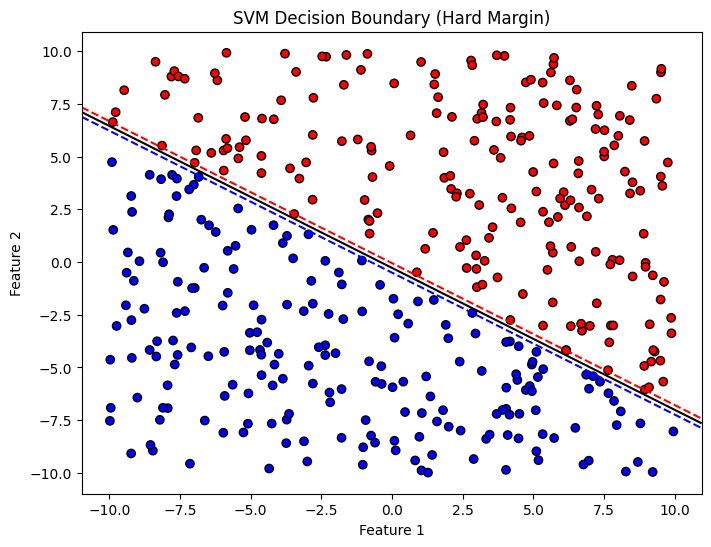

In [7]:
# Example usage
plot_svm_decision_boundary(model, X, y)

In [31]:
model_logistic, trained_plane_logistic = train_logistic_regression_gd(X,y_01,1000)

torch.Size([400, 1])
Epoch [1/1000], Loss: 1.1426
Epoch [100/1000], Loss: 0.5123
Epoch [200/1000], Loss: 0.3512
Epoch [300/1000], Loss: 0.2856
Epoch [400/1000], Loss: 0.2492
Epoch [500/1000], Loss: 0.2253
Epoch [600/1000], Loss: 0.2082
Epoch [700/1000], Loss: 0.1951
Epoch [800/1000], Loss: 0.1846
Epoch [900/1000], Loss: 0.1759
Epoch [1000/1000], Loss: 0.1686


In [32]:
print(trained_plane_logistic)

(-0.3208557963371277, 0.31113616, 0.48668316)


In [33]:
output = model_logistic(torch.tensor(X, dtype=torch.float32))

In [11]:
pred = output>0

In [34]:
score = 0
for i in range(400):
    if output[i,0] > 0 and y[i] >0:
        score += 1
    elif output[i,0] < 0 and y[i] <0:
        score += 1
print(score)

386


In [24]:
model_logistic.linear.weight, model_logistic.linear.bias

(Parameter containing:
 tensor([[0.4367, 0.6634]], requires_grad=True),
 Parameter containing:
 tensor([-0.5440], requires_grad=True))

In [25]:
def plot_line_from_coeffs(x, X):
    a0, a1, a2 = x

    # Domain for x1
    x1 = np.linspace(-10, 10, 400)

    # Avoid division by zero
    if a2 == 0:
        # Vertical line: a1 * x1 = -a0 ⇒ x1 = -a0 / a1
        x_val = -a0 / a1
        plt.axvline(x=x_val, color='red', label=f"x1 = {-a0/a1:.2f}")
    else:
        # Solve for x2
        x2 = -(a0 + a1 * x1) / a2
        plt.plot(x1, x2, label=f"{a0:+.1f} + {a1:+.1f}x₁ + {a2:+.1f}x₂ = 0")

    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.legend()
    plt.title(f"Plot of the line {x}")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    plt.show()

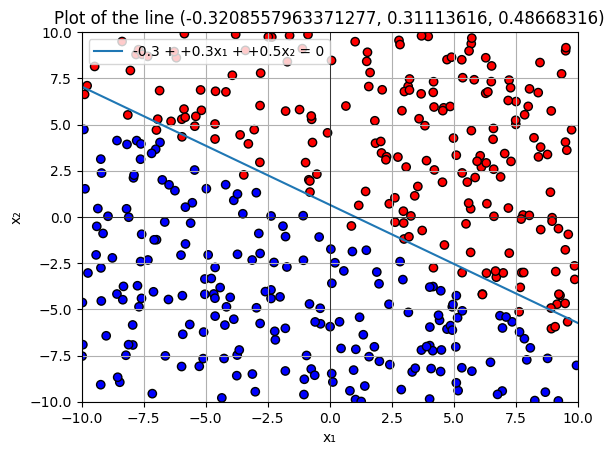

In [35]:
plot_line_from_coeffs(trained_plane_logistic, X)

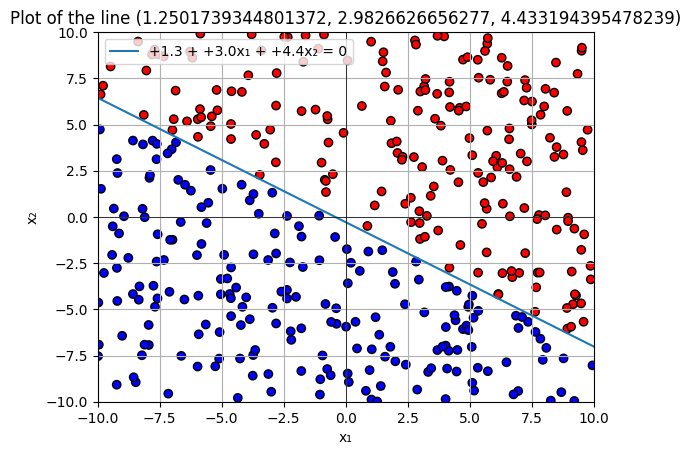

In [19]:
plot_line_from_coeffs(trained_plane, X)

In [27]:
trained_plane[2]/trained_plane[1]

1.4863210803442553

In [28]:
trained_plane_logistic[2]/trained_plane_logistic[1]

1.5191672